### Part-C Case Study

---

##### Case Study 1 – Student Performance Analytics
You are given data of 100 students containing their marks in Math, Science, and English.
- (a) Using Pandas, calculate the average marks for each student and identify the top 5 performers. 
- (b) Compute subject-wise average and standard deviation; comment which subject shows the highest variation. 
- (c) Draw a boxplot for each subject and comment on outliers.

In [1]:
# 1(a)
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df=pd.read_csv("Data/Students_Marks.csv")

# Calculate average marks
df['Average']=df[['Math','Science','English']].mean(axis=1)

# Top 5 performers
top=df.sort_values(by='Average',ascending=False).head(5)
print("Top Five Performers: \n",top[['Math','Science','English','Average']])

Top Five Performers: 
     Math  Science  English    Average
65    92       96       92  93.333333
0     78       96       99  91.000000
59    99       91       76  88.666667
33    83       99       84  88.666667
44    90       97       74  87.000000


In [2]:
# 1(b)
subject=df[['Math','Science','English']].agg(['mean','std'])
print("\nSubject-wise Average and Standard Deviation: \n",subject)
var=subject.loc['std'].idxmax()
print(f"\nSubject with highest variance: {var}")


Subject-wise Average and Standard Deviation: 
            Math    Science    English
mean  69.580000  66.880000  71.320000
std   18.031499  20.386805  15.868067

Subject with highest variance: Science


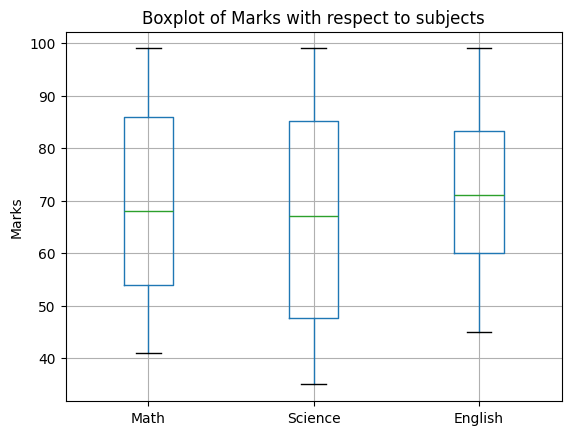

In [3]:
# 1(c)
df[['Math','Science','English']].boxplot()
plt.title("Boxplot of Marks with respect to subjects")
plt.ylabel("Marks")
plt.show()

In [4]:
# Outliers are present mainly in the lower ranges of Science and Math marks (<40),
# indicating a few students performed poorly in these subjects.
# English shows fewer outliers and less spread, meaning performance is more consistent.
# Science has the highest variation overall.

---

##### Case Study 2 – Sales Data Exploration
A company records sales transactions in a dataset with columns: Product, Quantity, Price, Region. 
- (a) Add a new column Total = Quantity × Price and compute overall revenue. 
- (b) Group data by region and identify which region contributes the most sales. 
- (c) Plot a histogram of total sales per product and discuss which products are underperforming.

In [5]:
# 2(a)
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df=pd.read_csv("Data/Sales_Data.csv")

# Add Total column and compute overall revenue
df['Total']=df['Quantity']*df['Price']
revenue=df['Total'].sum()
print("Overall Revenue:",revenue)

Overall Revenue: 1177230.1700000004


In [6]:
# 2(b)
region=df.groupby('Region')['Total'].sum().sort_values(ascending=False)
print("\nSales by Region: \n",region)
top=region.idxmax()
print(f"\nRegion with highest sales: {top}")


Sales by Region: 
 Region
South    369727.81
North    286862.46
East     274176.60
West     246463.30
Name: Total, dtype: float64

Region with highest sales: South


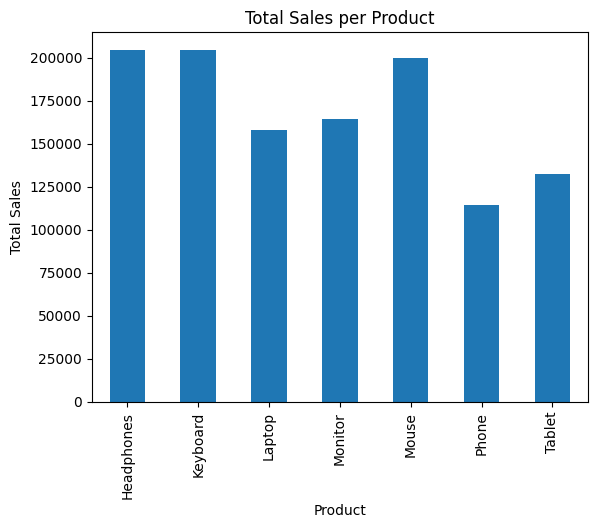

In [7]:
# 2(c)
product=df.groupby('Product')['Total'].sum()
product.plot(kind='bar',title='Total Sales per Product')
plt.ylabel('Total Sales')
plt.xlabel('Product')
plt.show()

In [8]:
# By the help of data visualization from the above bar graph we can simply state that
# Product - Phone is underperforming as the total sales is least when compared with other products available.

---

##### Case Study 3 – Predicting Fuel Efficiency (Auto MPG Dataset)
You are analyzing the Auto MPG dataset (UCI Repository) with features: mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin. 
- (a) Compute the correlation of mpg with each numeric feature and discuss which factors influence fuel efficiency most. 
- (b) Plot a scatter plot of weight vs mpg; describe the trend you observe.

In [9]:
# 3(a)
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

col=["mpg","cylinders","displacement","horsepower","weight", 
    "acceleration","model_year","origin","car_name"]

# Addinng the url to the data sets
df=pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data",
                names=col,delim_whitespace=True,na_values='?')

# Drop rows with missing horsepower or convert appropriately
df=df.dropna(subset=['horsepower'])
df['horsepower']=df['horsepower'].astype(float)

# Compute correlations of mpg with each numeric feature
corrs=df[['mpg','cylinders','displacement','horsepower', 
        'weight','acceleration','model_year','origin']].corr()['mpg'].drop('mpg')
print("Correlation of mpg with other features:\n",corrs.sort_values(ascending=False))

Correlation of mpg with other features:
 model_year      0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


In [10]:
# mpg shows strong negative correlation with weight, displacement, and horsepower,
# meaning heavier cars with larger engines tend to have lower fuel efficiency.
# Model year has a positive correlation with mpg, indicating newer models are more efficient.
# Cylinders also correlate negatively, as more cylinders generally reduce mpg.
# Hence, vehicle weight and engine power are the main factors influencing fuel efficiency.

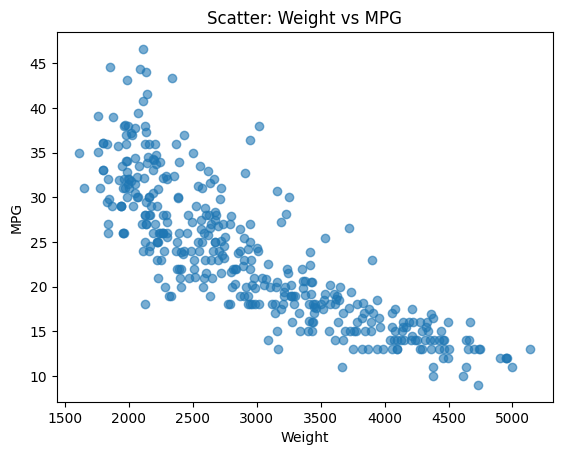

In [11]:
# 3(b)
plt.scatter(df['weight'],df['mpg'],alpha=0.6)
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Scatter: Weight vs MPG")
plt.show()

---